## Задание

1. Исправить ошибки в реализации Transformer.
2. Придумать свою задачу seq2seq и обучить на ней модель.
3. Сравнить ожидаемые зачения и предсказания модели.

In [ ]:
import math
import random
import re
from pathlib import Path
from random import randint

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from tqdm import tqdm

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, qk_norm: bool) -> None:
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        if qk_norm:
            self.q_norm = nn.LayerNorm(d_model)
            self.k_norm = nn.LayerNorm(d_model)
        else:
            self.q_norm = nn.Identity()
            self.k_norm = nn.Identity()

    def scaled_dot_product_attention(
        self, Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor, mask: torch.Tensor | None = None
    ) -> torch.Tensor:
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(
        self, Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor, mask: torch.Tensor | None = None
    ) -> torch.Tensor:
        Q = self.split_heads(self.q_norm(self.W_q(Q)))
        K = self.split_heads(self.k_norm(self.W_k(K)))
        V = self.split_heads(self.W_v(V))

        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))
        return output

In [ ]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, act: nn.Module) -> None:
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.act = act

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_seq_length: int) -> None:
        super().__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1)]

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: int, act: nn.Module, qk_norm: bool) -> None:
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, qk_norm)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, act)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        normed_x = self.norm1(x)
        attn_output = self.self_attn(normed_x, normed_x, normed_x, mask)
        x = x + self.dropout(attn_output)

        normed_x = self.norm2(x)
        ff_output = self.feed_forward(normed_x)
        x = x + self.dropout(ff_output)
        return x

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: int, act: nn.Module, qk_norm: bool) -> None:
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, qk_norm)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, qk_norm)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, act)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self, x: torch.Tensor, enc_output: torch.Tensor, src_mask: torch.Tensor, tgt_mask: torch.Tensor
    ) -> torch.Tensor:
        normed_x = self.norm1(x)
        attn_output = self.self_attn(normed_x, normed_x, normed_x, tgt_mask)
        x = x + self.dropout(attn_output)

        normed_x = self.norm2(x)
        attn_output = self.cross_attn(normed_x, enc_output, enc_output, src_mask)
        x = x + self.dropout(attn_output)

        normed_x = self.norm3(x)
        ff_output = self.feed_forward(normed_x)
        x = x + self.dropout(ff_output)
        return x

In [ ]:
class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab_size: int,
        tgt_vocab_size: int,
        d_model: int,
        num_heads: int,
        num_layers: int,
        d_ff: int,
        max_seq_length: int,
        dropout: float,
        device: str | torch.device,
        act: nn.Module = nn.ReLU(),
        qk_norm: bool = False,
        pad_token_idx: int | None = None,
    ) -> None:
        super().__init__()
        self.device = device
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=pad_token_idx)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=pad_token_idx)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, d_ff, dropout, act, qk_norm) for _ in range(num_layers)]
        )
        self.decoder_layers = nn.ModuleList(
            [DecoderLayer(d_model, num_heads, d_ff, dropout, act, qk_norm) for _ in range(num_layers)]
        )

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src: torch.Tensor, tgt: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2).to(self.device)
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(2).to(self.device)
        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool()
        tgt_mask = tgt_mask & nopeak_mask.to(self.device)

        return src_mask, tgt_mask

    def forward(self, src: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

        output = self.fc(dec_output)
        return output

In [ ]:
src_vocab_size = 1000
tgt_vocab_size = 2000
d_model = 512
num_heads = 8
num_layers = 6
d_ff = 2048
max_seq_length = 50
dropout = 0.1

In [ ]:
def generate_sample() -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    start = randint(1, 500)
    extra = 10

    src = torch.arange(start, start + max_seq_length + extra, dtype=torch.int64)
    trg = src + torch.arange(1, max_seq_length + extra + 1, dtype=torch.int64)
    labels = trg[1:]

    return src[:max_seq_length], trg[:max_seq_length], labels[:max_seq_length]

In [ ]:
def generate_batch(batch_size: int = 128) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    src_batch = torch.tensor([], dtype=torch.int64)
    trg_batch = torch.tensor([], dtype=torch.int64)
    labels_batch = torch.tensor([], dtype=torch.int64)

    while src_batch.shape[0] < batch_size:
        src_sample, trg_sample, labels_sample = generate_sample()
        src_batch = torch.cat((src_batch, src_sample.unsqueeze(0)))
        trg_batch = torch.cat((trg_batch, trg_sample.unsqueeze(0)))
        labels_batch = torch.cat((labels_batch, labels_sample.unsqueeze(0)))

    return src_batch, trg_batch, labels_batch

In [ ]:
pl.seed_everything(42, verbose=False)

device = "cuda" if torch.cuda.is_available() else "cpu"

transformer = Transformer(
    src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout, device
)
transformer = transformer.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-6)

transformer.train()
train_loss_history = []

for step in tqdm(range(100)):
    src_batch, trg_batch, labels_batch = generate_batch(64)
    optimizer.zero_grad()
    output = transformer(src_batch.to(device), trg_batch.to(device))
    loss = criterion(output.view(-1, output.size(-1)), labels_batch.to(device).view(-1))
    loss.backward()
    optimizer.step()
    train_loss_history.append(loss.item())
    # print(f"Step: {step+1}, Loss: {loss.item()}")

100%|██████████| 100/100 [00:23<00:00,  4.23it/s]


## Visualize train loss

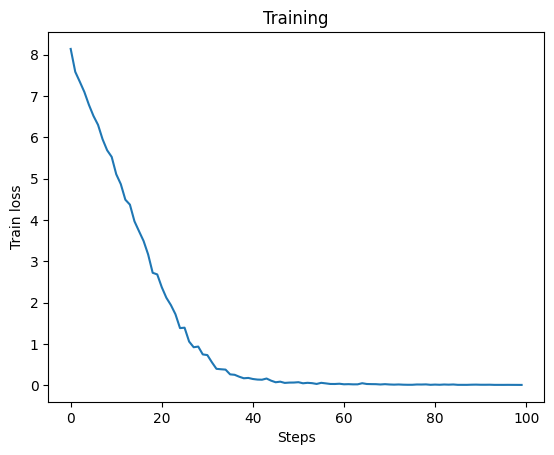

In [ ]:
# Define X and Y variable data
x = np.array(list(range(len(train_loss_history))))
y = np.array(train_loss_history)

plt.plot(x, y)
plt.xlabel("Steps")  # add X-axis label
plt.ylabel("Train loss")  # add Y-axis label
plt.title("Training")  # add title
plt.show()

## Другая активация

100%|██████████| 100/100 [00:23<00:00,  4.29it/s]


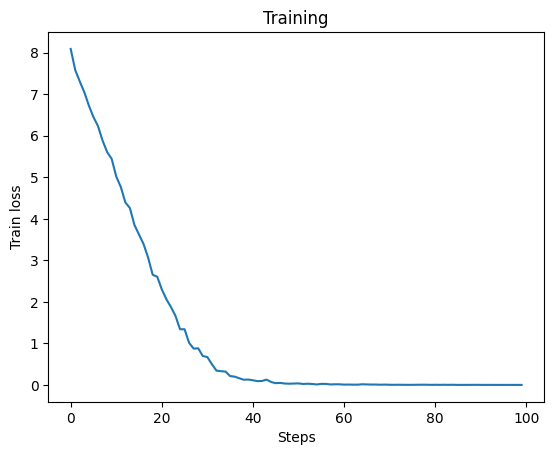

In [ ]:
pl.seed_everything(42, verbose=False)

transformer = Transformer(
    src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout, device, nn.SiLU()
)
transformer = transformer.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-6)

transformer.train()
train_loss_history = []

for step in tqdm(range(100)):
    src_batch, trg_batch, labels_batch = generate_batch(64)
    optimizer.zero_grad()
    output = transformer(src_batch.to(device), trg_batch.to(device))
    loss = criterion(output.view(-1, output.size(-1)), labels_batch.to(device).view(-1))
    loss.backward()
    optimizer.step()
    train_loss_history.append(loss.item())
    # print(f"Step: {step+1}, Loss: {loss.item()}")

# Define X and Y variable data
x = np.array(list(range(len(train_loss_history))))
y = np.array(train_loss_history)

plt.plot(x, y)
plt.xlabel("Steps")  # add X-axis label
plt.ylabel("Train loss")  # add Y-axis label
plt.title("Training")  # add title
plt.show()

## QK_Norm

100%|██████████| 100/100 [00:24<00:00,  4.11it/s]


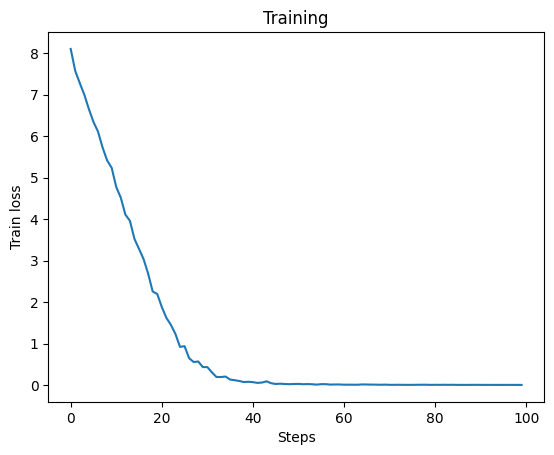

In [ ]:
pl.seed_everything(42, verbose=False)

transformer = Transformer(
    src_vocab_size,
    tgt_vocab_size,
    d_model,
    num_heads,
    num_layers,
    d_ff,
    max_seq_length,
    dropout,
    device,
    nn.SiLU(),
    True,
)
transformer = transformer.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-6)

transformer.train()
train_loss_history = []

for step in tqdm(range(100)):
    src_batch, trg_batch, labels_batch = generate_batch(64)
    optimizer.zero_grad()
    output = transformer(src_batch.to(device), trg_batch.to(device))
    loss = criterion(output.view(-1, output.size(-1)), labels_batch.to(device).view(-1))
    loss.backward()
    optimizer.step()
    train_loss_history.append(loss.item())
    # print(f"Step: {step+1}, Loss: {loss.item()}")

# Define X and Y variable data
x = np.array(list(range(len(train_loss_history))))
y = np.array(train_loss_history)

plt.plot(x, y)
plt.xlabel("Steps")  # add X-axis label
plt.ylabel("Train loss")  # add Y-axis label
plt.title("Training")  # add title
plt.show()

## Make batches for inference

In [ ]:
transformer.eval()
src_batch, trg_batch, labels_batch = generate_batch(64)

In [ ]:
preds_batch = torch.zeros_like(labels_batch)

In [ ]:
# predict from first token
trg_batch[:, 1:] = torch.full(trg_batch[:, 1:].shape, 0)

## Inference

In [ ]:
src_batch

tensor([[182, 183, 184,  ..., 229, 230, 231],
        [115, 116, 117,  ..., 162, 163, 164],
        [382, 383, 384,  ..., 429, 430, 431],
        ...,
        [ 30,  31,  32,  ...,  77,  78,  79],
        [  3,   4,   5,  ...,  50,  51,  52],
        [232, 233, 234,  ..., 279, 280, 281]])

In [ ]:
trg_batch

tensor([[183,   0,   0,  ...,   0,   0,   0],
        [116,   0,   0,  ...,   0,   0,   0],
        [383,   0,   0,  ...,   0,   0,   0],
        ...,
        [ 31,   0,   0,  ...,   0,   0,   0],
        [  4,   0,   0,  ...,   0,   0,   0],
        [233,   0,   0,  ...,   0,   0,   0]])

In [ ]:
preds_batch

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])

In [ ]:
# generating cycle
for i in range(trg_batch.shape[1]):
    res = transformer(src_batch.to(device), trg_batch.to(device))
    preds_batch[:, i] = res[:, i].argmax(dim=1)

    if i < trg_batch.shape[1] - 1:
        trg_batch[:, i + 1] = res[:, i].argmax(dim=1)

In [ ]:
preds_batch

tensor([[185, 187, 189,  ..., 279, 281, 283],
        [118, 120, 122,  ..., 212, 214, 216],
        [385, 387, 389,  ..., 479, 481, 483],
        ...,
        [ 33,  35,  37,  ..., 127, 129, 131],
        [  6,   8,  10,  ..., 100, 102, 104],
        [235, 237, 239,  ..., 329, 331, 333]])

In [ ]:
labels_batch

tensor([[185, 187, 189,  ..., 279, 281, 283],
        [118, 120, 122,  ..., 212, 214, 216],
        [385, 387, 389,  ..., 479, 481, 483],
        ...,
        [ 33,  35,  37,  ..., 127, 129, 131],
        [  6,   8,  10,  ..., 100, 102, 104],
        [235, 237, 239,  ..., 329, 331, 333]])

## Compare labels and preds here

In [ ]:
(preds_batch == labels_batch).sum(dim=-1) / preds_batch.size(dim=-1)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

# Seq2Seq

In [ ]:
class PhysicsDataset(data.Dataset):
    def __init__(self, num_samples: int = 50000, max_len: int = 30, verbose: bool = False) -> None:
        self.max_len = max_len

        chars = [
            "0",
            "1",
            "2",
            "3",
            "4",
            "5",
            "6",
            "7",
            "8",
            "9",
            ".",
            "-",
            " ",
            "C",
            "K",
            "P",
            "a",
            "d",
            "B",
            "f",
            "t",
            "t",
            "o",
            "m",
        ]

        self.chars = sorted(set(chars))

        self.pad_token = "<pad>"
        self.sos_token = "<sos>"
        self.eos_token = "<eos>"

        self.char_to_idx = {self.pad_token: 0, self.sos_token: 1, self.eos_token: 2}
        self.idx_to_char = {0: self.pad_token, 1: self.sos_token, 2: self.eos_token}

        for i, ch in enumerate(self.chars):
            idx = i + 3
            self.char_to_idx[ch] = idx
            self.idx_to_char[idx] = ch

        self.vocab_size = len(self.chars) + 3

        self.pairs = []
        self._generate_data(num_samples)

        if verbose:
            print(f"Generated {len(self.pairs)} physics conversion pairs")
            print(f"Vocab size: {self.vocab_size}")
            print(f"Example 1: {self.pairs[0][0]} -> {self.pairs[0][1]}")
            print(f"Example 2: {self.pairs[1][0]} -> {self.pairs[1][1]}")
            print(f"Example 3: {self.pairs[2][0]} -> {self.pairs[2][1]}")

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, index: int):
        src, tgt = self.pairs[index]
        return torch.tensor(self.encode_input(src), dtype=torch.long), torch.tensor(
            self.encode_target(tgt), dtype=torch.long
        )

    def _generate_data(self, num_samples: int) -> None:
        for _ in range(num_samples):
            task_type = random.choice(["temp", "sound", "length"])

            if task_type == "temp":
                src, tgt = self._generate_temp_pair()
            elif task_type == "sound":
                src, tgt = self._generate_sound_pair()
            else:
                src, tgt = self._generate_length_pair()

            self.pairs.append((src, tgt))

    def _format_num(self, num: float) -> str:
        return f"{num:.2f}"

    def _generate_temp_pair(self) -> tuple[str, str]:
        c_k_coef = 273.15

        if random.random() > 0.5:
            c_val = random.uniform(-273.15, 1000)
            k_val = c_val + c_k_coef
            src_str = f"{self._format_num(c_val)} C to K"
            tgt_str = f"{self._format_num(k_val)} K"
        else:
            k_val = random.uniform(0, 1273.15)
            c_val = k_val - c_k_coef
            src_str = f"{self._format_num(k_val)} K to C"
            tgt_str = f"{self._format_num(c_val)} C"
        return src_str, tgt_str

    def _generate_length_pair(self) -> tuple[str, str]:
        m_ft_coef = 0.3048

        if random.random() > 0.5:
            m_val = random.uniform(-100, 100)
            ft_val = m_val / m_ft_coef
            src_str = f"{self._format_num(m_val)} m to ft"
            tgt_str = f"{self._format_num(ft_val)} ft"
        else:
            ft_val = random.uniform(-30.48, 30.48)
            m_val = ft_val * m_ft_coef
            src_str = f"{self._format_num(ft_val)} ft to m"
            tgt_str = f"{self._format_num(m_val)} m"
        return src_str, tgt_str

    def _generate_sound_pair(self) -> tuple[str, str]:
        P0 = 2e-5

        if random.random() > 0.5:
            pa_val = random.uniform(2e-3, 2)
            db_val = 20 * (math.log10(pa_val / P0))
            src_str = f"{self._format_num(pa_val)} Pa to dB"
            tgt_str = f"{self._format_num(db_val)} dB"
        else:
            db_val = random.uniform(0, 100)
            pa_val = P0 * (10 ** (db_val / 20))
            src_str = f"{self._format_num(db_val)} dB to Pa"
            tgt_str = f"{self._format_num(pa_val)} Pa"
        return src_str, tgt_str

    def encode_input(self, text: int) -> list[int]:
        indices = [self.char_to_idx.get(ch, self.char_to_idx[self.pad_token]) for ch in text[: self.max_len]]
        if len(indices) < self.max_len:
            indices += [self.char_to_idx[self.pad_token]] * (self.max_len - len(indices))
        return indices

    def encode_target(self, text: str) -> list[int]:
        indices = [self.char_to_idx[self.sos_token]]

        for ch in text[: self.max_len - 2]:
            indices.append(self.char_to_idx.get(ch, 0))
        indices.append(self.char_to_idx[self.eos_token])

        if len(indices) < self.max_len:
            indices += [0] * (self.max_len - len(indices))

        if len(indices) > self.max_len:
            indices = indices[: self.max_len]
        return indices

    def decode(self, indices: list[int] | torch.Tensor) -> str:
        if torch.is_tensor(indices):
            indices = indices.tolist()

        result = []
        for idx in indices:
            if idx == self.char_to_idx[self.eos_token]:
                break
            if idx == self.char_to_idx[self.sos_token] or idx == self.char_to_idx[self.pad_token]:
                continue
            if idx in self.idx_to_char:
                result.append(self.idx_to_char[idx])
        return "".join(result).strip()

In [ ]:
dataset = PhysicsDataset(num_samples=1000, max_len=25, verbose=True)

print("Example:")
for i in range(4):
    src_tensor, tgt_tensor = dataset[i]
    input_text_reconstructed = dataset.decode(src_tensor)

    target_text_reconstructed = dataset.decode(tgt_tensor)

    print(f"Input Tensor Decoded : {input_text_reconstructed}")
    print(f"Target Tensor Decoded: {target_text_reconstructed}")

    print("-" * 20)

Generated 1000 physics conversion pairs
Vocab size: 26
Example 1: 77.35 dB to Pa -> 0.15 Pa
Example 2: -2.08 m to ft -> -6.84 ft
Example 3: 552.18 K to C -> 279.03 C
Example:
Input Tensor Decoded : 77.35 dB to Pa
Target Tensor Decoded: 0.15 Pa
--------------------
Input Tensor Decoded : -2.08 m to ft
Target Tensor Decoded: -6.84 ft
--------------------
Input Tensor Decoded : 552.18 K to C
Target Tensor Decoded: 279.03 C
--------------------
Input Tensor Decoded : 96.53 dB to Pa
Target Tensor Decoded: 1.34 Pa
--------------------


In [ ]:
def extract_value(text: str, epoch: int = 0) -> float:
    text = text.strip()
    if not text:
        if epoch > 1:
            print("unmatched", text)
        return 100.0

    text = re.sub(r"\.+", ".", text)

    if re.match(r"^[-\.]+", text) and not re.match(r"^-?\d+\.", text):
        text = re.sub(r"^([-\.]+)", lambda m: "0" + m.group(0).replace(".", ""), text)

    pattern = r"-?\d*\.?\d+"
    matched_str = re.match(pattern, text)
    if matched_str is not None:
        return float(matched_str.group())
    if epoch > 1:
        print("unmatched", text)
    return 100.0


def mse(src: list[float], tgt: list[float]) -> float:
    return math.sqrt(sum((one_src - one_tgt) ** 2 for one_src, one_tgt in zip(src, tgt)) / len(src))


def train(device):
    pl.seed_everything(42, verbose=False)

    batch_size = 64
    epochs = 15
    max_len = 30

    train_dataset = PhysicsDataset(num_samples=40_000, max_len=max_len)
    train_loader = data.DataLoader(
        train_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True, drop_last=True
    )

    val_dataset = PhysicsDataset(num_samples=5_000, max_len=max_len)
    val_loader = data.DataLoader(val_dataset, batch_size, num_workers=2, pin_memory=True)

    num_batches = len(train_dataset) // batch_size

    model = Transformer(
        src_vocab_size=dataset.vocab_size,
        tgt_vocab_size=dataset.vocab_size,
        d_model=128,
        num_heads=4,
        num_layers=3,
        d_ff=512,
        max_seq_length=max_len,
        dropout=0.1,
        device=device,
        act=nn.SiLU(),
        qk_norm=True,
        pad_token_idx=dataset.char_to_idx[dataset.pad_token],
    )
    model.to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_loss = float("inf")

    losses = []
    mses = []
    token_accuracies = []

    for epoch in range(epochs):
        epoch_loss = 0
        epoch_token_accuracy = 0
        epoch_mse = 0

        model.train()
        for src, tgt in tqdm(train_loader, desc="Training epoch", leave=False):
            src, tgt = src.to(device, non_blocking=True), tgt.to(device, non_blocking=True)
            tgt_in = tgt[:, :-1]
            tgt_out = tgt[:, 1:]

            out = model(src, tgt_in)
            loss = criterion(out.reshape(-1, dataset.vocab_size), tgt_out.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        for src, tgt in tqdm(val_loader, desc="Validating epoch", leave=False):
            src, tgt = src.to(device, non_blocking=True), tgt.to(device, non_blocking=True)
            tgt_in = tgt[:, :-1]
            tgt_out = tgt[:, 1:]

            with torch.inference_mode():
                out = model(src, tgt_in)
                out = out.argmax(-1)

            loss = criterion(out.reshape(-1, dataset.vocab_size), tgt_out.reshape(-1))
            out_pred_value = [extract_value(dataset.decode(o), epoch) for o in out]
            tgt_out_value = [extract_value(dataset.decode(t), epoch) for t in tgt_out]

            epoch_loss += loss.item()
            epoch_token_accuracy += (tgt_out == out).to(torch.float32).mean().cpu().item()
            epoch_mse += mse(out_pred_value, tgt_out_value)

        avg_loss = epoch_loss / num_batches
        avg_token_accuracy = epoch_token_accuracy / num_batches
        avg_mse = epoch_mse / num_batches

        print(f"Epoch {epoch + 1}/{epochs}", end=" ")
        if avg_loss < best_loss:
            best_loss = avg_loss
            print(f"New best loss: {best_loss:.4f}", end="; ")
            torch.save(model.state_dict(), "checkpoints/best_transformer.pth")
        else:
            print(f"loss: {avg_loss:.4f}", end="; ")

        print(f"Token accuracy: {avg_token_accuracy:.4f}; MSE: {avg_mse:.4f}")

        losses.append(avg_loss)
        token_accuracies.append(avg_token_accuracy)
        mses.append(avg_mse)

    return model, max_len, losses, token_accuracies, mses

In [ ]:
@torch.inference_mode()
def test(model: Transformer, dataset: PhysicsDataset) -> None:
    model.eval()

    for i in range(8):
        src, tgt = dataset[i]
        src, tgt = src.to(model.device), tgt.to(model.device)
        src, tgt = src.unsqueeze(0), tgt.unsqueeze(0)

        tgt_in = tgt[:, :-1]

        out = model(src, tgt_in).argmax(dim=-1)

        print("Task:", dataset.decode(src[0]))
        print("GT:       ", dataset.decode(tgt[0]))
        print("Predicted:", dataset.decode(out[0]))
        print("=" * 20)

Epoch 1/15 New best loss: 0.7864; Token accuracy: 0.3505; MSE: 33649.2390


Epoch 2/15 New best loss: 0.4247; Token accuracy: 0.6590; MSE: 14454.2555


Epoch 3/15 New best loss: 0.3269; Token accuracy: 0.6521; MSE: 8976.3051


Training epoch:  56%|█████▋    | 352/625 [00:10<00:09, 28.00it/s]

unmatched C.47 C


...

unmatched C.49 K


Epoch 14/15 New best loss: 0.1681; Token accuracy: 0.8100; MSE: 5777.8878


Training epoch:   0%|          | 1/625 [00:00<01:12,  8.55it/s]

tensor([ 4,  8, 11, 14,  5, 11,  7,  3, 22, 25,  2,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0], device='cuda:0'), tensor([ 4,  8, 11, 14,  5, 10,  8,  3, 22, 25,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2,  2,  2,  2,  2,  3,  2,  2,  2,  2], device='cuda:0')


Epoch 15/15 New best loss: 0.1534; Token accuracy: 0.8837; MSE: 641.5313


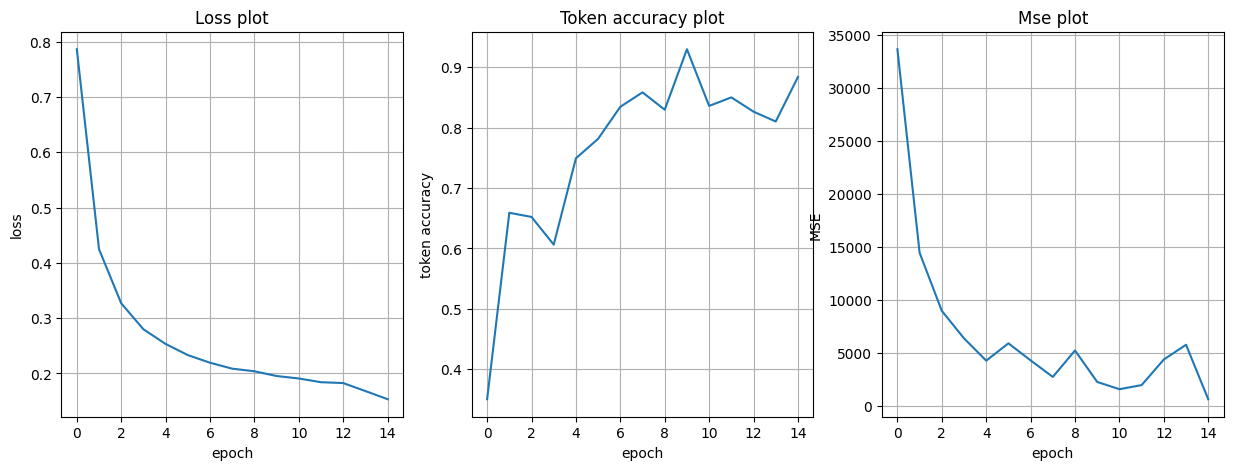

In [ ]:
model, max_len, losses, token_accuracies, mses = train(device)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))


def plot(values: list[float], name: str, idx: int) -> None:
    ax[idx].plot(values)
    ax[idx].set_xlabel("epoch")
    ax[idx].set_ylabel(name)
    ax[idx].set_title(f"{name.capitalize()} plot")
    ax[idx].grid(True)


for idx, (name, values) in enumerate(zip(["loss", "token accuracy", "MSE"], [losses, token_accuracies, mses])):
    plot(values, name, idx)
plt.show()

In [ ]:
default_path = "checkpoints/best_transformer.pth"
if Path(default_path).exists():
    print("Loading best model")
    model.load_state_dict(torch.load(default_path))

test_dataset = PhysicsDataset(10, max_len=max_len)
test(model, test_dataset)

Loading best model
Task: 14.72 ft to m
GT:        4.49 m
Predicted: 4.48 m
Task: 937.64 K to C
GT:        664.49 C
Predicted: 664.49 C
Task: 9.07 m to ft
GT:        29.77 ft
Predicted: 29.77 ft
Task: -28.66 ft to m
GT:        -8.74 m
Predicted: -8.74 m
Task: 766.46 K to C
GT:        493.31 C
Predicted: 493.31 C
Task: 9.14 ft to m
GT:        2.78 m
Predicted: 2.79 m
Task: -3.10 ft to m
GT:        -0.94 m
Predicted: -0.94 m
Task: 0.01 Pa to dB
GT:        57.49 dB
Predicted: 53.47 dB


In [ ]:
text = "0.01 Pa to dB 9.14 ft to m"
tgt_text = "57.49 dB 2.78 m"
src = torch.tensor(dataset.encode_input(text), device=model.device)
tgt = torch.tensor(dataset.encode_input(tgt_text), device=model.device)

with torch.inference_mode():
    src, tgt = src.unsqueeze(0), tgt.unsqueeze(0)
    tgt_in = tgt[:, :-1]
    out = model(src, tgt_in).argmax(dim=-1)

print("Task:", dataset.decode(src[0]))
print("GT:       ", dataset.decode(tgt[0]))
print("Predicted:", dataset.decode(out[0]))
print("=" * 20)

Task: 0.01 Pa to dB 9.14 ft to m
GT:        57.49 dB 2.78 m
Predicted: ..6  dB


# Выводы

По архитектуре:
- Починил forward у энкодера и декодера
- Поменял post-LN на pre-LN
- Добавил возможность менять функцию у FFN (SiLU чуть быстрее сошёлся, более гладкий график, нет проблемы отмирания нейронов)
- Добавил возможность применять QK-Нормализацию (ещё чуть быстрее сходимость)

По обучению:
- Обучили модель для конвертации физических величин в обе стороны